<a href="https://colab.research.google.com/github/Augusta02/assessment_meritinc/blob/main/meritinc_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torch torchvision opencv-python albumentations torchmetrics tqdm

In [4]:
import zipfile
import os

from google.colab import drive
drive.mount('/content/drive')
ZIP_PATH    = "/content/drive/MyDrive/data/loveda.zip"
EXTRACT_DIR = "/content/data"

# Extract
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

# Confirm structure
os.listdir(EXTRACT_DIR)

Mounted at /content/drive
Extracted ✅


['LoveDA']

In [11]:
from glob import glob

image_paths = sorted(glob("/content/data/LoveDA/images_png/*.png"))
mask_paths  = sorted(glob("/content/data/LoveDA/masks_png/*.png"))

assert len(image_paths) > 0, "No images found — check extraction path"
assert len(image_paths) == len(mask_paths), f"Mismatch: {len(image_paths)} images vs {len(mask_paths)} masks"

print(f"Total images : {len(image_paths)}")
print(f"Total masks  : {len(mask_paths)}")

Total images : 4191
Total masks  : 4191


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from tqdm import tqdm
from torchmetrics import JaccardIndex
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from glob import glob
import os

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Device  : cuda
PyTorch : 2.11.0+cu128


In [25]:
# constants
NUM_CLASSES = 7

LOVEDA_PALETTE = np.array([
    [0,   0,   0],
    [255, 0,   0],
    [255, 255, 0],
    [0,   0,   255],
    [159, 129, 183],
    [0,   255, 0],
    [255, 195, 128],
], dtype=np.uint8)

LOVEDA_CLASSES = {
    0: "Background", 1: "Building", 2: "Road",
    3: "Water",      4: "Barren",   5: "Forest", 6: "Agriculture"
}


In [ ]:
"""
Loveda data all images have each pixels with provided data,
Our context. when given sparse data fro each pixel, can we get the complete image

Simulate Point labels would help create sparse data in our dataset,
From a full mask it would randomly pick N pixels per class.
Returns a point_mask — same size as the original mask
"""
def simulate_point_labels(mask, num_points_per_class=5):
    point_mask = np.zeros_like(mask)
    classes    = np.unique(mask)
    for cls in classes:
        rows, cols = np.where(mask == cls)
        n_sample   = min(num_points_per_class, len(rows))
        chosen     = np.random.choice(len(rows), size=n_sample, replace=False)
        point_mask[rows[chosen], cols[chosen]] = 1
    return point_mask



In [43]:
"""
Partial Cross Entrop (PCE) is a loss function similar to standard
Cross Entropy but instead of computing the loss over every pixel in
the image, it only computes the loss over pixels that have been labeled.
here we would be working with less 30% of labeled data
"""

def partial_cross_entropy_loss(predictions, masks, point_masks, ignore_index=-1):
    """
    Computes cross entropy only over labeled pixels (point_masks == 1).

    predictions :raw logits from UNet
    masks       : full ground truth class indices
    point_masks : 1 = labeled, 0 = ignore
    """
    sparse_gt = masks.clone().long()
    sparse_gt[point_masks == 0] = ignore_index

    return F.cross_entropy(
        predictions,
        sparse_gt,
        ignore_index=ignore_index,
        reduction="mean"
    )



partial_cross_entropy_loss defined ✅


In [44]:
"""
LoveDAPointDataset is a custom PyTorch Dataset class that loads the LoveDA
remote sensing dataset and simulates sparse point label annotations.
"""

class LoveDAPointDataset(Dataset):
  #
    def __init__(self, image_paths, mask_paths,
                 num_points_per_class=5, transforms=None,
                 img_size=256):
        self.image_paths          = image_paths
        self.mask_paths           = mask_paths
        self.num_points_per_class = num_points_per_class
        self.transforms           = transforms
        self.img_size             = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask  = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask  = np.clip(mask - 1, 0, 6).astype(np.uint8)

        # resize to smaller size for memory and speed
        image = cv2.resize(image, (self.img_size, self.img_size),interpolation=cv2.INTER_LINEAR)
        mask  = cv2.resize(mask,  (self.img_size, self.img_size),interpolation=cv2.INTER_NEAREST)

        # simulate point labels on resized mask
        point_mask = simulate_point_labels(mask, self.num_points_per_class)

        image      = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask       = torch.from_numpy(mask).long()
        point_mask = torch.from_numpy(point_mask).long()

        return image, mask, point_mask

In [29]:
# Split image and mask paths into train / val / test
total   = len(image_paths)
n_train = int(total * 0.70)
n_val   = int(total * 0.15)

torch.manual_seed(42)
indices = torch.randperm(total).tolist()

train_image_paths = [image_paths[i] for i in indices[:n_train]]
train_mask_paths  = [mask_paths[i]  for i in indices[:n_train]]

val_image_paths   = [image_paths[i] for i in indices[n_train:n_train + n_val]]
val_mask_paths    = [mask_paths[i]  for i in indices[n_train:n_train + n_val]]

test_image_paths  = [image_paths[i] for i in indices[n_train + n_val:]]
test_mask_paths   = [mask_paths[i]  for i in indices[n_train + n_val:]]

print(f"Train : {len(train_image_paths)}")
print(f"Val   : {len(val_image_paths)}")
print(f"Test  : {len(test_image_paths)}")

Train : 2933
Val   : 628
Test  : 630


In [30]:
train_dataset = LoveDAPointDataset(train_image_paths, train_mask_paths,num_points_per_class=5, img_size=256)
val_dataset = LoveDAPointDataset(val_image_paths, val_mask_paths,num_points_per_class=5, img_size=256)
test_dataset = LoveDAPointDataset(test_image_paths, test_mask_paths,num_points_per_class=5, img_size=256)

train_loader = DataLoader(train_dataset, batch_size=8,shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=8,shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=1,shuffle=False, num_workers=2)

# print train data
images, masks, point_masks = next(iter(train_loader))
print(f"Images      : {images.shape}")
print(f"Masks       : {masks.shape}")
print(f"Point masks : {point_masks.shape}")

Images      : torch.Size([8, 3, 256, 256])
Masks       : torch.Size([8, 256, 256])
Point masks : torch.Size([8, 256, 256])


## UNet Logic

In [31]:
"""
Model Applied:
UNet a convolutional neural network designed for biomedical
image segmentation and remote sensing segmentatio.

Its U-shaped architecture — the network
compresses the input image and then decodes, reconstructs it back to the original spatial size, producing a
class prediction for every single pixel."""

class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.pool  = nn.MaxPool2d(kernel_size=2)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x, self.pool(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv1    = nn.Conv2d(in_channels + skip_channels, in_channels, kernel_size=3, padding=1)
        self.conv2    = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1      = nn.BatchNorm2d(in_channels)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)

    def forward(self, x, skip):
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=7):
        super().__init__()
        self.enc1 = EncoderBlock(in_channels, 32)
        self.enc2 = EncoderBlock(32, 64)
        self.enc3 = EncoderBlock(64, 128)
        self.enc4 = EncoderBlock(128, 256)

        self.bridge = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        self.dec1 = DecoderBlock(256, 256, 256)
        self.dec2 = DecoderBlock(256, 128, 128)
        self.dec3 = DecoderBlock(128, 64,  64)
        self.dec4 = DecoderBlock(64,  32,  32)

        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        skip1, x = self.enc1(x)
        skip2, x = self.enc2(x)
        skip3, x = self.enc3(x)
        skip4, x = self.enc4(x)

        x = self.bridge(x)

        x = self.dec1(x, skip4)
        x = self.dec2(x, skip3)
        x = self.dec3(x, skip2)
        x = self.dec4(x, skip1)

        return self.final_conv(x)


# test with one batch
model  = UNet(in_channels=3, num_classes=7).to(DEVICE)
images = images.to(DEVICE)

with torch.no_grad():
    output = model(images)

total_params = sum(p.numel() for p in model.parameters())

print(f"Input shape       : {images.shape}")
print(f"Output shape      : {output.shape}")
print(f"Total parameters  : {total_params:,}")

Input shape       : torch.Size([8, 3, 256, 256])
Output shape      : torch.Size([8, 7, 256, 256])
Total parameters  : 6,857,319


In [32]:


def train_one_epoch(model, loader, optimizer, device):
    """
    One full pass through the training set.
    Uses partial CE loss — gradients only flow through labeled pixels.
    """
    model.train()
    total_loss = 0.0
    iou_metric = JaccardIndex(task="multiclass", num_classes=7).to(device)

    pbar = tqdm(loader, desc="  Train", leave=False)
    for images, masks, point_masks in pbar:
        images      = images.to(device)
        masks       = masks.to(device)
        point_masks = point_masks.to(device)

        # forward pass
        optimizer.zero_grad()
        predictions = model(images)

        # partial ce loss — only labeled pixels
        loss = partial_cross_entropy_loss(predictions, masks, point_masks)

        # bbackward pass
        loss.backward()
        optimizer.step()

        # Track metrics
        pred_classes = predictions.argmax(dim=1)
        iou_metric.update(pred_classes, masks)
        total_loss  += loss.item() * images.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "mIoU": f"{iou_metric.compute().item():.4f}",
        })

    avg_loss = total_loss / len(loader.dataset)
    avg_iou  = iou_metric.compute().item()
    return avg_loss, avg_iou



# validate model
def validate(model, loader, device):
    """
    Validation pass.
    Loss computed on point labels — mIoU evaluated on full masks.
    """
    model.eval()
    total_loss = 0.0
    iou_metric = JaccardIndex(task="multiclass", num_classes=7).to(device)

    with torch.no_grad():
        pbar = tqdm(loader, desc="  Val  ", leave=False)
        for images, masks, point_masks in pbar:
            images      = images.to(device)
            masks       = masks.to(device)
            point_masks = point_masks.to(device)

            predictions  = model(images)
            loss         = partial_cross_entropy_loss(predictions, masks, point_masks)
            pred_classes = predictions.argmax(dim=1)

            iou_metric.update(pred_classes, masks)
            total_loss  += loss.item() * images.size(0)

            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "mIoU": f"{iou_metric.compute().item():.4f}",
            })

    avg_loss = total_loss / len(loader.dataset)
    avg_iou  = iou_metric.compute().item()
    return avg_loss, avg_iou


# run fit on model, if validation improves save
# notify by printing at each completion
# if improved or not
def fit(model, train_loader, val_loader, epochs, lr, device,
        checkpoint_path="best_model.pth"):
    """
    Full training loop with validation and best model checkpointing.
    """
    optimizer     = torch.optim.Adam(model.parameters(), lr=lr)
    best_val_loss = float("inf")

    result = {
        "train_loss": [], "train_iou": [],
        "val_loss":   [], "val_iou":   [],
    }

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")
        print("-" * 40)

        train_loss, train_iou = train_one_epoch(model, train_loader, optimizer, device)
        val_loss,   val_iou   = validate(model, val_loader, device)

        print(f"  train_loss : {train_loss:.4f}  train_mIoU : {train_iou:.4f}")
        print(f"  val_loss   : {val_loss:.4f}  val_mIoU   : {val_iou:.4f}")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), checkpoint_path)
            print(f" Best model saved {checkpoint_path}")
        else:
            print(f" No improvement (best: {best_val_loss:.4f})")

        result["train_loss"].append(train_loss)
        result["train_iou"].append(train_iou)
        result["val_loss"].append(val_loss)
        result["val_iou"].append(val_iou)

    return result

In [33]:
# run model for 10 epochs
# each shoul return train loss, iou, val loss and its iou
# stores the best model in best_model_path
EPOCHS = 10
LR     = 1e-4

model = UNet(in_channels=3, num_classes=7).to(DEVICE)

print(f"Training on  : {DEVICE}")
print(f"Epochs       : {EPOCHS}")
print(f"LR           : {LR}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Loss         : Partial CE (5 points/class)")
print("-" * 40)

result = fit(
    model       = model,
    train_loader= train_loader,
    val_loader  = val_loader,
    epochs      = EPOCHS,
    lr          = LR,
    device      = DEVICE,
    checkpoint_path = "best_model_5pts.pth"
)

Training on  : cuda
Epochs       : 10
LR           : 0.0001
Train batches: 367
Val batches  : 79
Loss         : Partial CE (5 points/class)
----------------------------------------

Epoch 1/10
----------------------------------------


  train_loss : 1.4809  train_mIoU : 0.2377
  val_loss   : 1.3502  val_mIoU   : 0.2996
 Best model saved best_model_5pts.pth

Epoch 2/10
----------------------------------------


  train_loss : 1.2971  train_mIoU : 0.2899
  val_loss   : 1.2180  val_mIoU   : 0.3347
 Best model saved best_model_5pts.pth

Epoch 3/10
----------------------------------------


  train_loss : 1.2011  train_mIoU : 0.3190
  val_loss   : 1.1481  val_mIoU   : 0.3491
 Best model saved best_model_5pts.pth

Epoch 4/10
----------------------------------------


  train_loss : 1.1361  train_mIoU : 0.3349
  val_loss   : 1.0987  val_mIoU   : 0.3789
 Best model saved best_model_5pts.pth

Epoch 5/10
----------------------------------------


...

  train_loss : 1.0682  train_mIoU : 0.3549
  val_loss   : 1.0186  val_mIoU   : 0.4005
 Best model saved best_model_5pts.pth

Epoch 7/10
----------------------------------------


  train_loss : 1.0351  train_mIoU : 0.3626
  val_loss   : 1.0279  val_mIoU   : 0.4008
 No improvement (best: 1.0186)

Epoch 8/10
----------------------------------------


  train_loss : 1.0030  train_mIoU : 0.3776
  val_loss   : 0.9908  val_mIoU   : 0.4174
 Best model saved best_model_5pts.pth

Epoch 9/10
----------------------------------------


  train_loss : 0.9838  train_mIoU : 0.3834
  val_loss   : 0.9821  val_mIoU   : 0.4086
 Best model saved best_model_5pts.pth

Epoch 10/10
----------------------------------------


  train_loss : 0.9667  train_mIoU : 0.3910
  val_loss   : 0.9642  val_mIoU   : 0.4199
 Best model saved best_model_5pts.pth


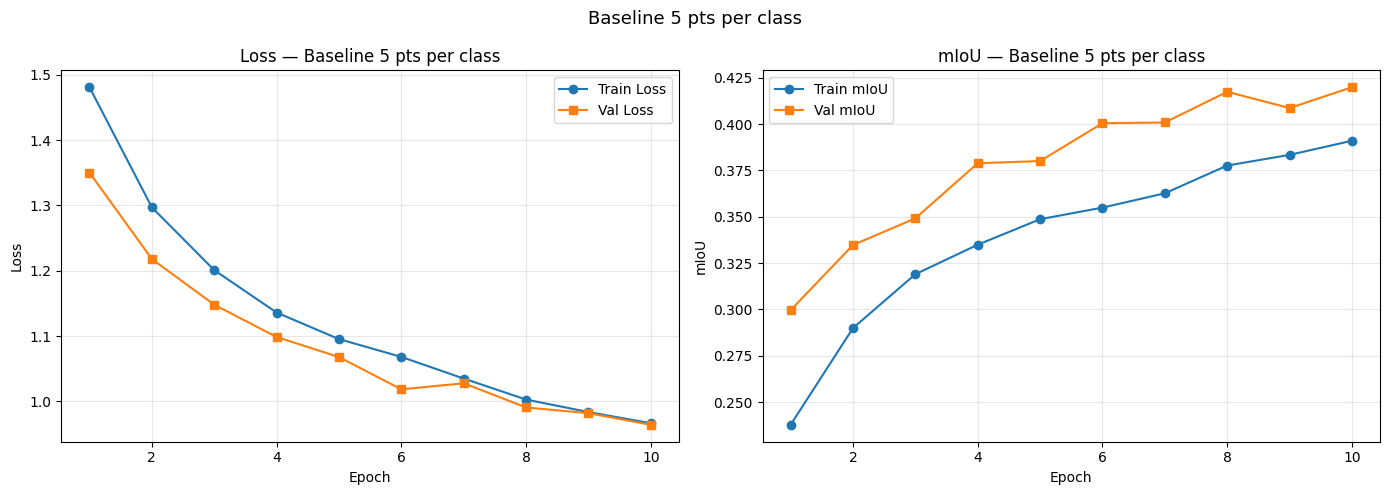

In [35]:
# plot the train loss, train iou, val loss and iou
def plot_training_curves(result, title=""):
    epochs = range(1, len(result["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, result["train_loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, result["val_loss"],   marker="s", label="Val Loss")
    axes[0].set_title(f"Loss — {title}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, result["train_iou"], marker="o", label="Train mIoU")
    axes[1].plot(epochs, result["val_iou"],   marker="s", label="Val mIoU")
    axes[1].set_title(f"mIoU — {title}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("mIoU")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()


    ux = title.replace("/", "_").replace(" ", "_").replace("—", "-")
    plt.savefig(f"curves_{ux}.png", dpi=150)
    plt.show()

# Plot baseline
plot_training_curves(result, title="Baseline 5 points per class")


  Experiment — num_points_per_class = 1

Epoch 1/10
----------------------------------------


  train_loss : 0.9782  train_mIoU : 0.3789
  val_loss   : 0.9963  val_mIoU   : 0.4037
 Best model saved best_model_1pts.pth

Epoch 2/10
----------------------------------------


  train_loss : 0.9830  train_mIoU : 0.3837
  val_loss   : 1.0090  val_mIoU   : 0.4211
 No improvement (best: 0.9963)

Epoch 3/10
----------------------------------------


  train_loss : 0.9833  train_mIoU : 0.3820
  val_loss   : 1.0119  val_mIoU   : 0.4021
 No improvement (best: 0.9963)

Epoch 4/10
----------------------------------------


  train_loss : 0.9619  train_mIoU : 0.3838
  val_loss   : 0.9880  val_mIoU   : 0.4320
 Best model saved best_model_1pts.pth

Epoch 5/10
----------------------------------------


...

  train_loss : 0.9470  train_mIoU : 0.3959
  val_loss   : 0.9568  val_mIoU   : 0.4280
 Best model saved best_model_1pts.pth

Epoch 7/10
----------------------------------------


  train_loss : 0.9413  train_mIoU : 0.3971
  val_loss   : 0.9655  val_mIoU   : 0.4393
 No improvement (best: 0.9568)

Epoch 8/10
----------------------------------------


  train_loss : 0.9275  train_mIoU : 0.3985
  val_loss   : 0.9760  val_mIoU   : 0.4165
 No improvement (best: 0.9568)

Epoch 9/10
----------------------------------------


  train_loss : 0.9336  train_mIoU : 0.4029
  val_loss   : 0.9727  val_mIoU   : 0.4386
 No improvement (best: 0.9568)

Epoch 10/10
----------------------------------------


  train_loss : 0.9039  train_mIoU : 0.4076
  val_loss   : 0.9544  val_mIoU   : 0.4253
 Best model saved best_model_1pts.pth

  Best val mIoU (1 pts/class): 0.4393


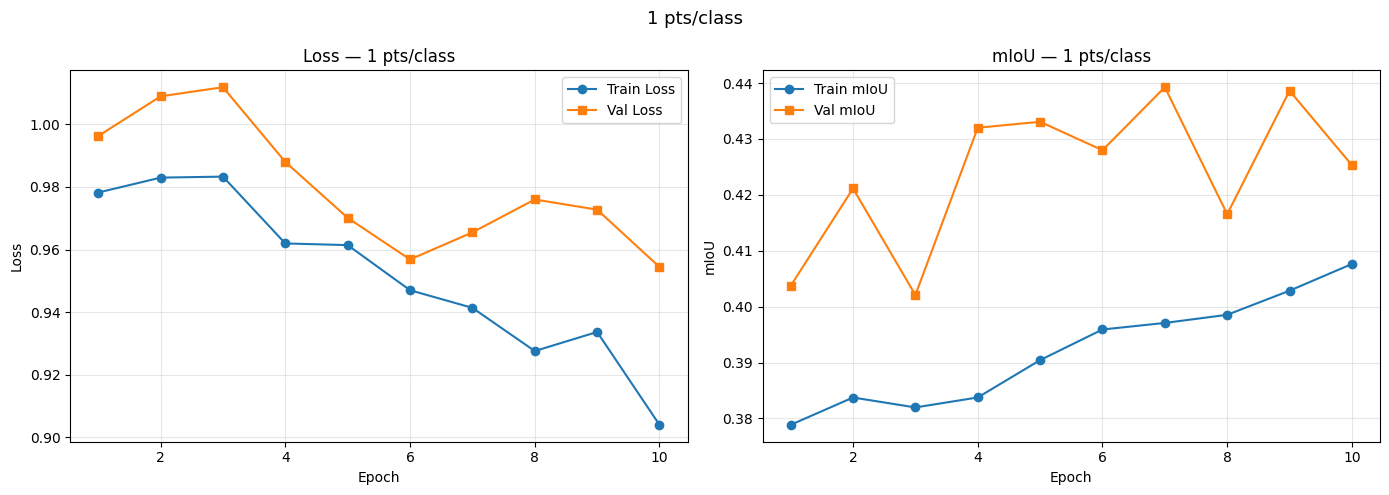


  Experiment — num_points_per_class = 3

Epoch 1/10
----------------------------------------


  train_loss : 0.8937  train_mIoU : 0.4137
  val_loss   : 0.9538  val_mIoU   : 0.4428
 Best model saved best_model_3pts.pth

Epoch 2/10
----------------------------------------


  train_loss : 0.8747  train_mIoU : 0.4185
  val_loss   : 0.9001  val_mIoU   : 0.4490
 Best model saved best_model_3pts.pth

Epoch 3/10
----------------------------------------


  train_loss : 0.8533  train_mIoU : 0.4287
  val_loss   : 0.9048  val_mIoU   : 0.4514
 No improvement (best: 0.9001)

Epoch 4/10
----------------------------------------


  train_loss : 0.8425  train_mIoU : 0.4296
  val_loss   : 0.9304  val_mIoU   : 0.4629
 No improvement (best: 0.9001)

Epoch 5/10
----------------------------------------


...

  train_loss : 0.8228  train_mIoU : 0.4370
  val_loss   : 0.9101  val_mIoU   : 0.4666
 No improvement (best: 0.9001)

Epoch 7/10
----------------------------------------


  train_loss : 0.8028  train_mIoU : 0.4446
  val_loss   : 0.8900  val_mIoU   : 0.4770
 Best model saved best_model_3pts.pth

Epoch 8/10
----------------------------------------


  train_loss : 0.7926  train_mIoU : 0.4487
  val_loss   : 0.9086  val_mIoU   : 0.4693
 No improvement (best: 0.8900)

Epoch 9/10
----------------------------------------


  train_loss : 0.7837  train_mIoU : 0.4461
  val_loss   : 0.9026  val_mIoU   : 0.4586
 No improvement (best: 0.8900)

Epoch 10/10
----------------------------------------


  train_loss : 0.7739  train_mIoU : 0.4505
  val_loss   : 0.8996  val_mIoU   : 0.4830
 No improvement (best: 0.8900)

  Best val mIoU (3 pts/class): 0.4830


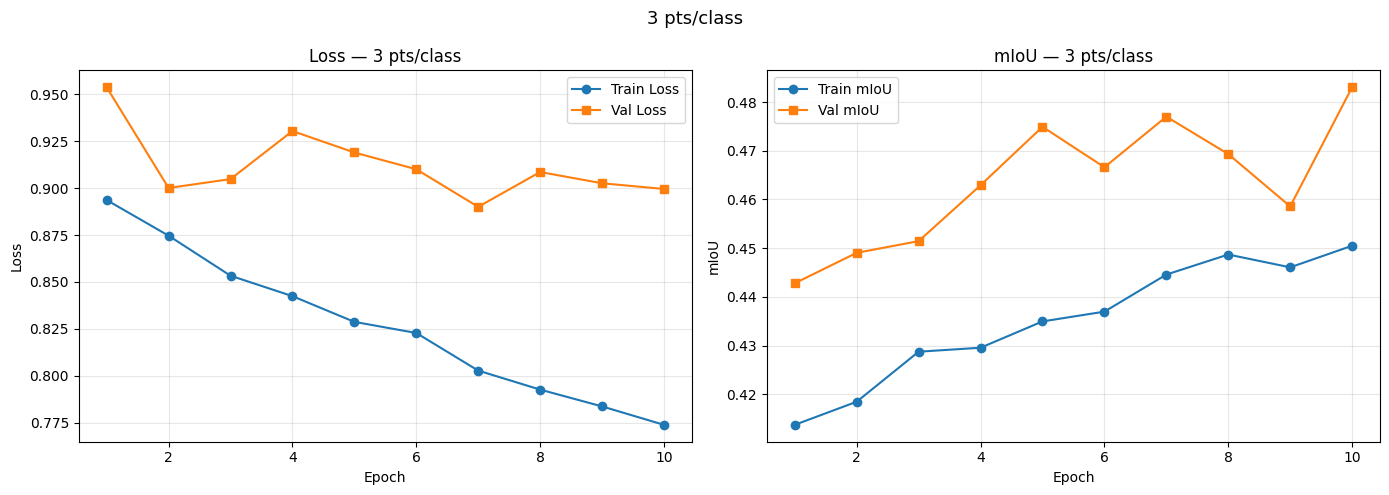


  Experiment — num_points_per_class = 10

Epoch 1/10
----------------------------------------


  train_loss : 0.7479  train_mIoU : 0.4620
  val_loss   : 0.8884  val_mIoU   : 0.4736
 Best model saved best_model_10pts.pth

Epoch 2/10
----------------------------------------


  train_loss : 0.7281  train_mIoU : 0.4706
  val_loss   : 0.8932  val_mIoU   : 0.4745
 No improvement (best: 0.8884)

Epoch 3/10
----------------------------------------


  train_loss : 0.7047  train_mIoU : 0.4756
  val_loss   : 0.8831  val_mIoU   : 0.4825
 Best model saved best_model_10pts.pth

Epoch 4/10
----------------------------------------


  train_loss : 0.6902  train_mIoU : 0.4828
  val_loss   : 0.8879  val_mIoU   : 0.4869
 No improvement (best: 0.8831)

Epoch 5/10
----------------------------------------


...

  train_loss : 0.6677  train_mIoU : 0.4891
  val_loss   : 0.8937  val_mIoU   : 0.4877
 No improvement (best: 0.8831)

Epoch 7/10
----------------------------------------


  train_loss : 0.6455  train_mIoU : 0.4973
  val_loss   : 0.8983  val_mIoU   : 0.5104
 No improvement (best: 0.8831)

Epoch 8/10
----------------------------------------


  train_loss : 0.6355  train_mIoU : 0.5016
  val_loss   : 0.9286  val_mIoU   : 0.4954
 No improvement (best: 0.8831)

Epoch 9/10
----------------------------------------


  train_loss : 0.6199  train_mIoU : 0.5094
  val_loss   : 0.9240  val_mIoU   : 0.4942
 No improvement (best: 0.8831)

Epoch 10/10
----------------------------------------


  train_loss : 0.6171  train_mIoU : 0.5091
  val_loss   : 0.9151  val_mIoU   : 0.5009
 No improvement (best: 0.8831)

  Best val mIoU (10 pts/class): 0.5104


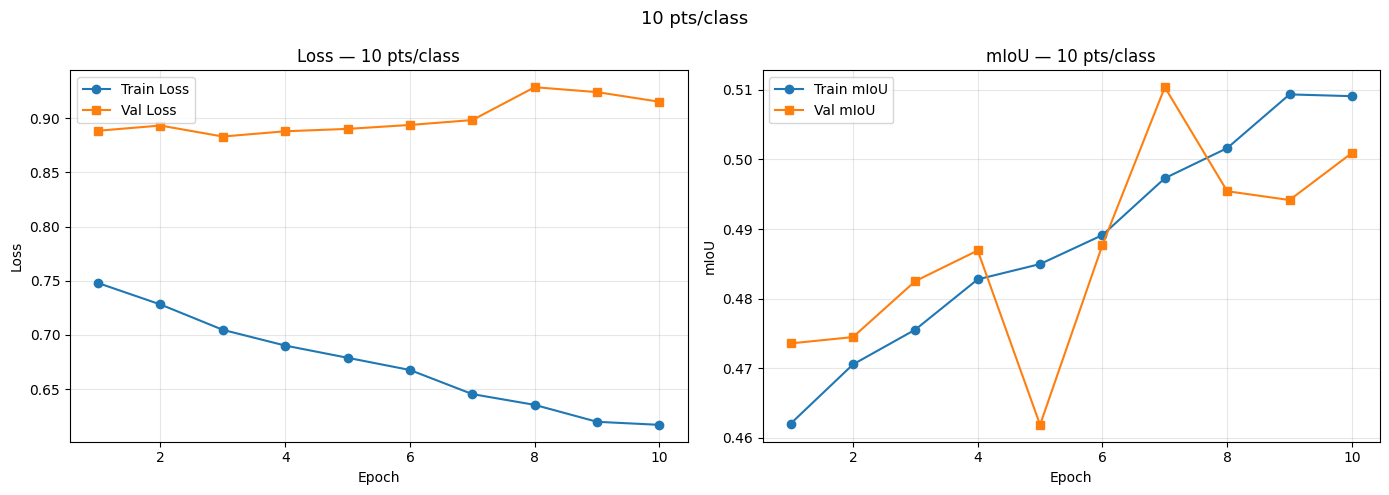


── Experiment 1 Summary ──────────────────────────────
   pts/class |  Best Val mIoU
  ----------------------------
           1 |         0.4393
           3 |         0.4830
           5 |         0.4199
          10 |         0.5104


In [37]:
# Experiment 1: vary num_points_per_class which performs best more or less points
# Hypothesis: more points = better mIoU, with diminishing returns

def run_experiment(num_points, epochs=10, lr=1e-4, img_size=256, batch_size=8):
    print(f"  Experiment — num_points_per_class = {num_points}")


    # trai
    hist = fit(
        model        = m,
        train_loader = train_loader,
        val_loader   = val_loader,
        epochs       = epochs,
        lr           = lr,
        device       = DEVICE,
        checkpoint_path = f"best_model_{num_points}pts.pth"
    )

    best_val_iou = max(hist["val_iou"])
    print(f"\n Best val mIoU ({num_points} pts/class): {best_val_iou:.4f}")
    return hist, best_val_iou


#  define varying point density
point_density = [1, 3, 5, 10]
exp1_results    = {}

for pt in point_density:
    hist, best_iou      = run_experiment(num_points=pt)
    exp1_results[pt] = (hist, best_iou)
    plot_training_curves(hist, title=f"{pt} pts/class")

print("\n── Experiment 1 Summary ")
print(f"  {'pts/class':>10} | {'Best Val mIoU':>14}")
for n in sorted(exp1_results.keys()):
    print(f"  {n:>10} | {exp1_results[n][1]:>14.4f}")

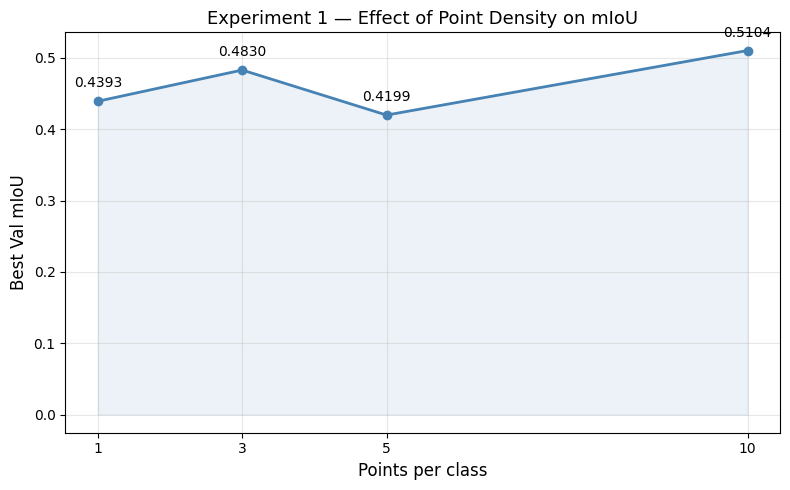

In [38]:
pts   = sorted(exp1_results.keys())
mious = [exp1_results[n][1] for n in pts]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pts, mious, marker="o", linewidth=2, color="steelblue")
ax.fill_between(pts, mious, alpha=0.1, color="steelblue")

for x, y in zip(pts, mious):
    ax.annotate(f"{y:.4f}", (x, y),
                textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=10)

ax.set_xlabel("Points per class", fontsize=12)
ax.set_ylabel("Best Val mIoU",    fontsize=12)
ax.set_title("Experiment 1 — Effect of Point Density on mIoU", fontsize=13)
ax.set_xticks(pts)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("exp1_point_density.png", dpi=150)
plt.show()

## Experiment 2: what is the performance between Standard CE with full annotations vs Partial CE.

In [41]:
def full_supervision_loss(predictions, masks, point_masks):
    """
    Standard Cross Entropy over ALL pixels,  ignores point_masks entirely.
    Same signature as partial_cross_entropy_loss so training loop works unchanged.
    """
    return F.cross_entropy(predictions, masks.long(), reduction="mean")



In [42]:
# run  using already defined data
# for full supervision change loss function

m_full    = model
optimizer = torch.optim.Adam(m_full.parameters(), lr=1e-4)

best_val_loss = float("inf")
hist_full = {"train_loss": [], "train_iou": [],
             "val_loss":   [], "val_iou":   []}

for epoch in range(1, 11):
    #  Train
    m_full.train()
    total_loss = 0.0
    iou_metric = JaccardIndex(task="multiclass", num_classes=7).to(DEVICE)

    pbar = tqdm(train_loader, desc=f"  [Full] Train", leave=False)
    for images, masks, point_masks in pbar:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        optimizer.zero_grad()
        preds = m_full(images)
        # all pixels
        loss  = full_supervision_loss(preds, masks, point_masks)
        loss.backward()
        optimizer.step()

        iou_metric.update(preds.argmax(dim=1), masks)
        total_loss += loss.item() * images.size(0)

    train_loss = total_loss / len(train_loader.dataset)
    train_iou  = iou_metric.compute().item()

    # validate
    m_full.eval()
    total_loss = 0.0
    iou_metric = JaccardIndex(task="multiclass", num_classes=7).to(DEVICE)

    with torch.no_grad():
        for images, masks, point_masks in val_loader:
            images = images.to(DEVICE)
            masks  = masks.to(DEVICE)
            preds  = m_full(images)
            loss   = full_supervision_loss(preds, masks, point_masks)

            iou_metric.update(preds.argmax(dim=1), masks)
            total_loss += loss.item() * images.size(0)

    val_loss = total_loss / len(val_loader.dataset)
    val_iou  = iou_metric.compute().item()

    print(f"Epoch {epoch}/10 — "
          f"train_loss: {train_loss:.4f}  train_mIoU: {train_iou:.4f}  "
          f"val_loss: {val_loss:.4f}  val_mIoU: {val_iou:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(m_full.state_dict(), "best_full_supervision.pth")
        print("Best model saved")

    hist_full["train_loss"].append(train_loss)
    hist_full["train_iou"].append(train_iou)
    hist_full["val_loss"].append(val_loss)
    hist_full["val_iou"].append(val_iou)

#summary of results
best_full    = max(hist_full["val_iou"])
best_partial = exp1_results[10][1]

print("\n── Experiment 2 Summary ───")
print(f"  {'Condition':<30} | {'Best Val mIoU':>14}")
print("  " + "-"*48)
print(f"  {'Full Supervision (all pixels)':<30} | {best_full:>14.4f}")
print(f"  {'Partial CE (10 pts/class)':<30} | {best_partial:>14.4f}")
gap = best_full - best_partial
print(f"\n  Gap (full - partial)  : {gap:.4f} mIoU points")
print(f"  Partial CE recovers   : {(best_partial/best_full)*100:.1f}% of full supervision")

  Epoch 1/10 — train_loss: 0.6677  train_mIoU: 0.5743  val_loss: 0.6667  val_mIoU: 0.5692
  ✅ Best model saved


  Epoch 2/10 — train_loss: 0.6351  train_mIoU: 0.5890  val_loss: 0.6881  val_mIoU: 0.5640


  Epoch 3/10 — train_loss: 0.6155  train_mIoU: 0.5970  val_loss: 0.7400  val_mIoU: 0.5386


  Epoch 4/10 — train_loss: 0.6019  train_mIoU: 0.6046  val_loss: 0.6702  val_mIoU: 0.5670


  Epoch 5/10 — train_loss: 0.5746  train_mIoU: 0.6219  val_loss: 0.6476  val_mIoU: 0.5744
  ✅ Best model saved


  Epoch 6/10 — train_loss: 0.5653  train_mIoU: 0.6262  val_loss: 0.7502  val_mIoU: 0.5425


  Epoch 7/10 — train_loss: 0.5478  train_mIoU: 0.6370  val_loss: 0.7159  val_mIoU: 0.5587


  Epoch 8/10 — train_loss: 0.5285  train_mIoU: 0.6462  val_loss: 0.6591  val_mIoU: 0.5802


  Epoch 9/10 — train_loss: 0.5045  train_mIoU: 0.6590  val_loss: 0.7839  val_mIoU: 0.5294


  Epoch 10/10 — train_loss: 0.4918  train_mIoU: 0.6691  val_loss: 0.6687  val_mIoU: 0.5768

── Experiment 2 Summary ──────────────────────────────────
  Condition                      |  Best Val mIoU
  ------------------------------------------------
  Full Supervision (all pixels)  |         0.5802
  Partial CE (10 pts/class)      |         0.5104

  Gap (full - partial)  : 0.0698 mIoU points
  Partial CE recovers   : 88.0% of full supervision


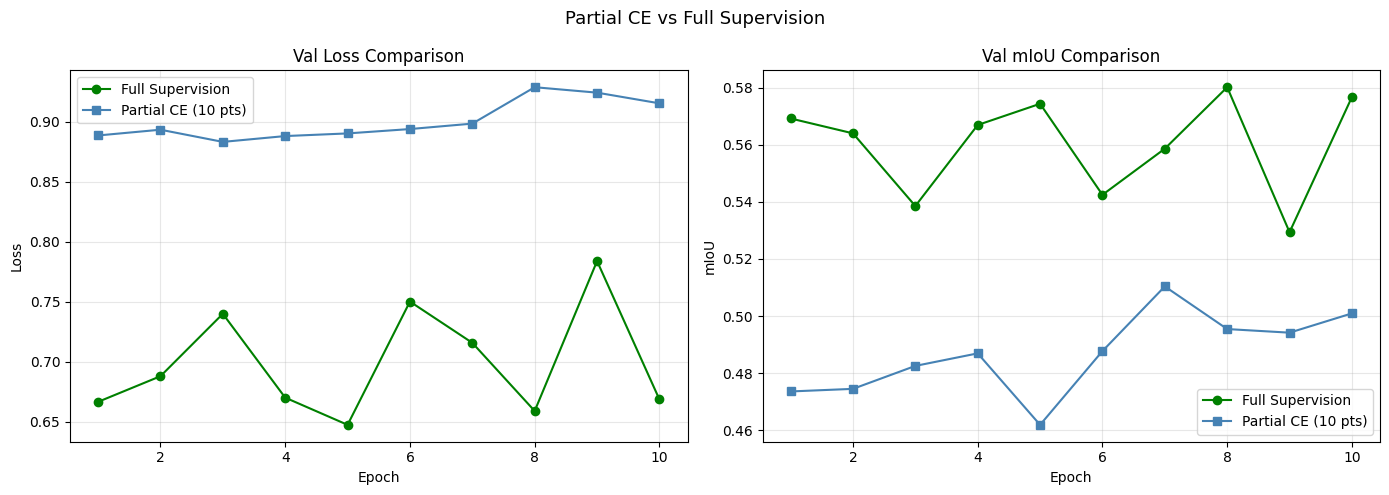

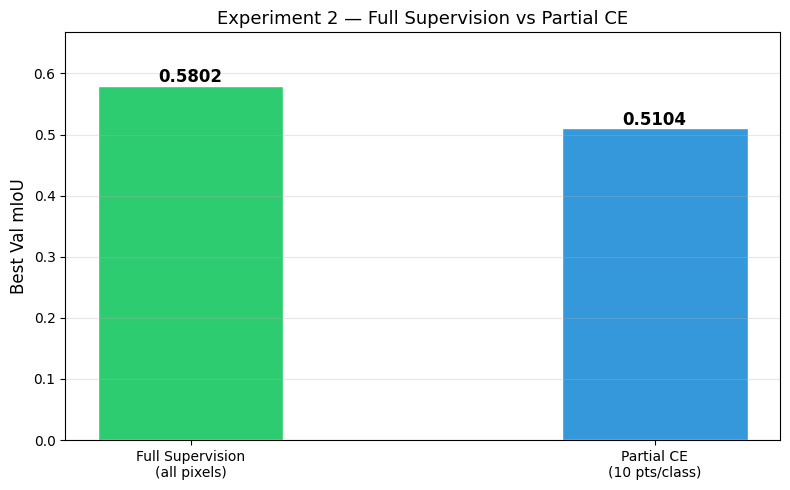

In [45]:
# Side by side training curves
epochs = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hist_partial = exp1_results[10][0]
best_partial = exp1_results[10][1]

# Loss
axes[0].plot(epochs, hist_full["val_loss"],    marker="o",
             label="Full Supervision", color="green")
axes[0].plot(epochs, hist_partial["val_loss"], marker="s",
             label="Partial CE", color="steelblue")
axes[0].set_title("Val Loss Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# mIoU
axes[1].plot(epochs, hist_full["val_iou"],    marker="o",
             label="Full Supervision", color="green")
axes[1].plot(epochs, hist_partial["val_iou"], marker="s",
             label="Partial CE", color="steelblue")
axes[1].set_title("Val mIoU Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mIoU")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Partial CE vs Full Supervision", fontsize=13)
plt.tight_layout()
plt.savefig("exp2_comparison.png", dpi=150)
plt.show()

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
conditions = ["all pixels", "10 pts/class"]
values     = [best_full, best_partial]
colors     = ["#2ecc71", "#3498db"]

bars = ax.bar(conditions, values, color=colors, width=0.4, edgecolor="white")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v:.4f}", ha="center", fontsize=12, fontweight="bold")

ax.set_ylim(0, max(values) * 1.15)
ax.set_ylabel("Best Validation mIoU", fontsize=12)
ax.set_title("Experiment 2: Full Supervision vs Partial CE", fontsize=13)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("exp2_bar.png", dpi=150)
plt.show()

## Model On Test Data

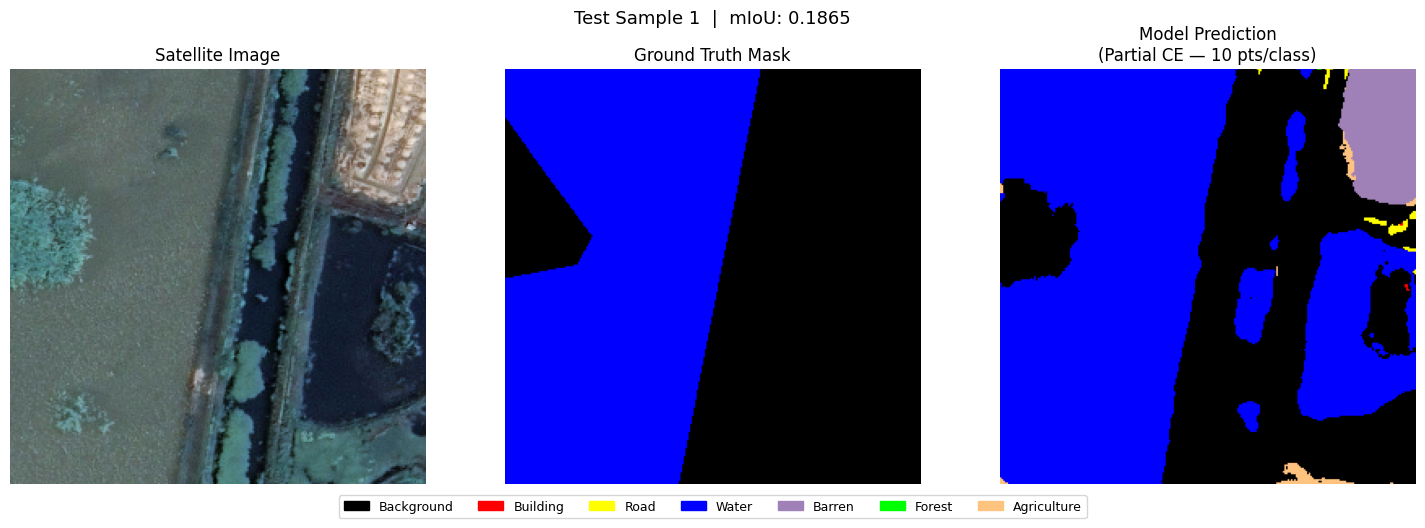

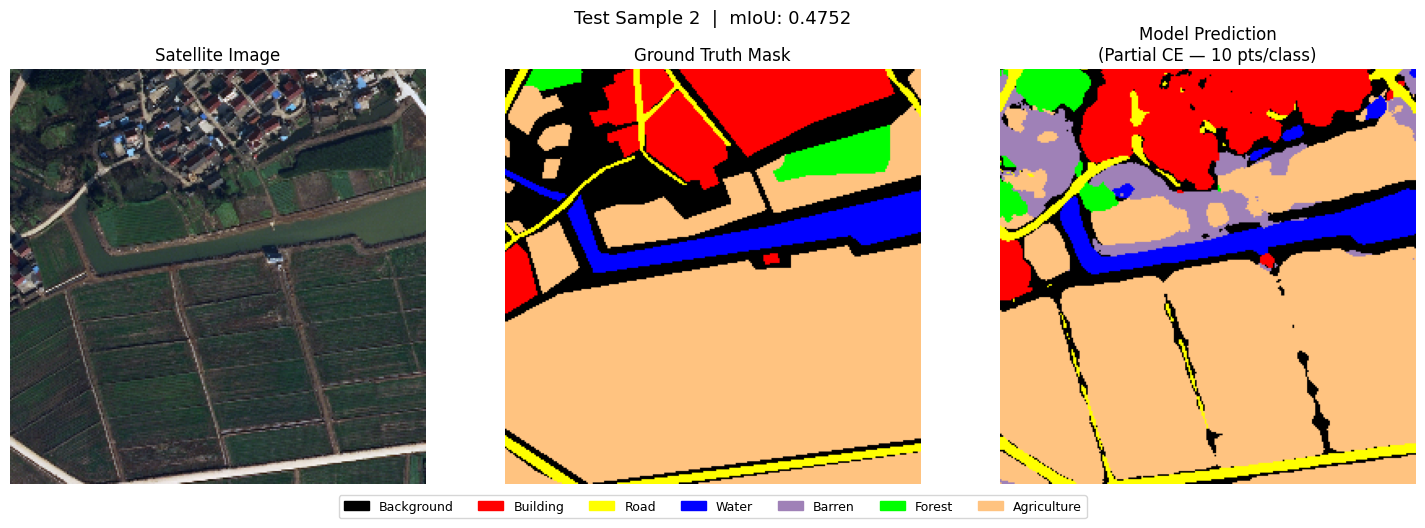

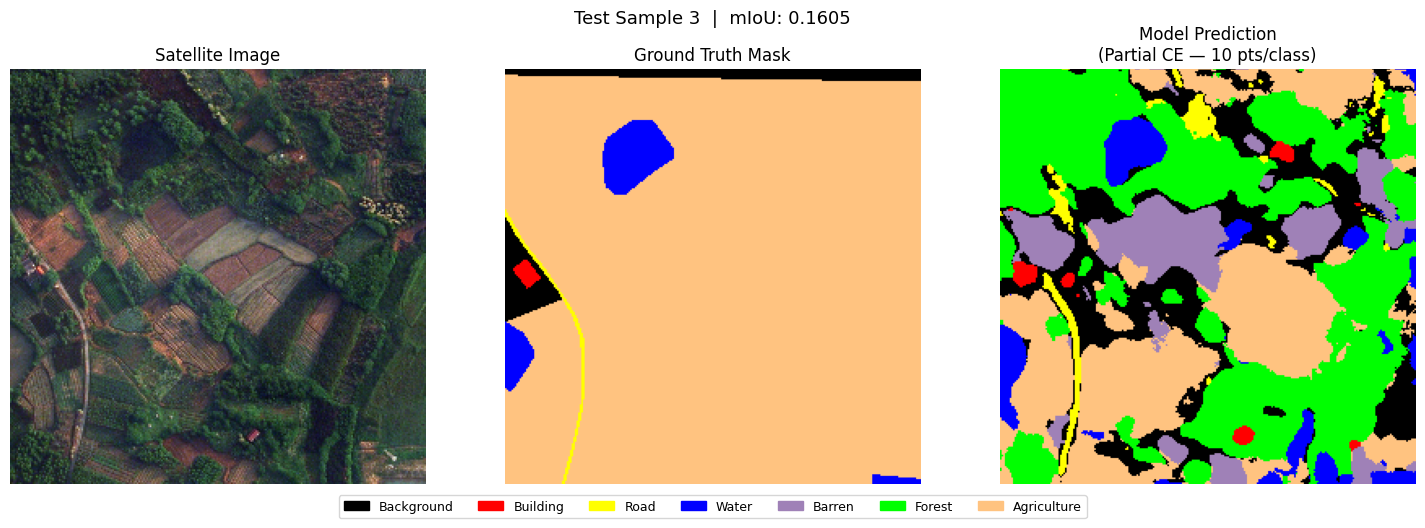

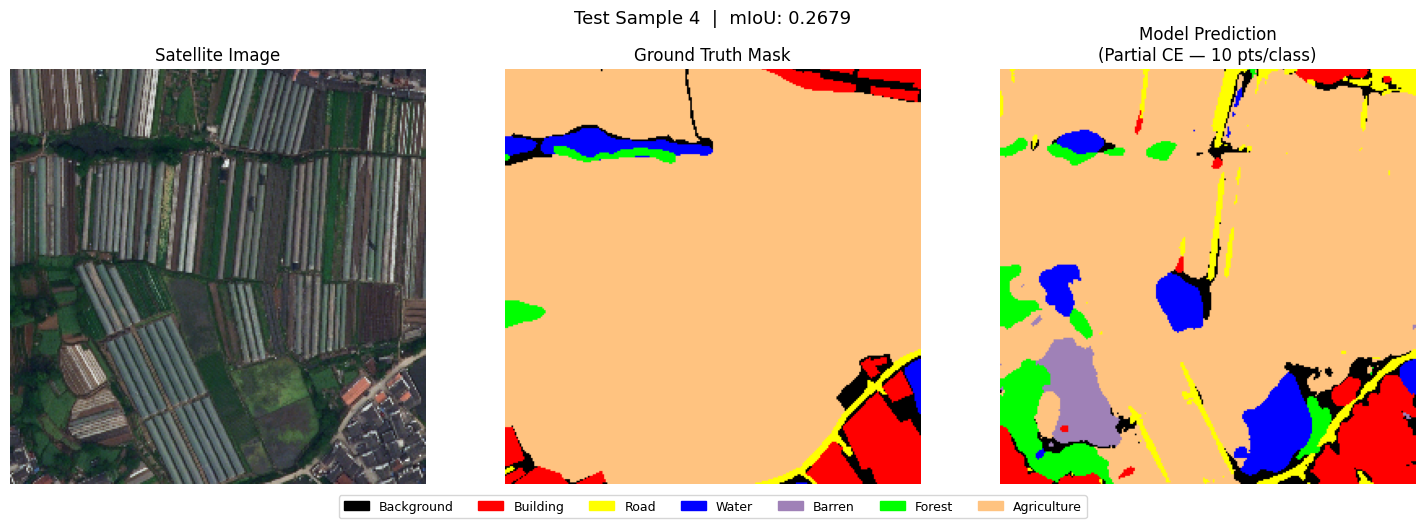

In [46]:
# load best model to test data
best_model = model
best_model.load_state_dict(torch.load("best_model_10pts.pth", map_location=DEVICE))
best_model.eval()


# run inference on test data
def visualise_predictions(model, test_loader, num_samples=4, device=DEVICE):

    model.eval()
    samples_shown = 0

    with torch.no_grad():
        for images, masks, _ in test_loader:
            images = images.to(device)
            preds  = model(images)
            preds  = preds.argmax(dim=1).cpu().numpy()
            images = images.cpu()
            masks  = masks.numpy()

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    return

                img_np   = images[i].permute(1, 2, 0).numpy()
                img_np   = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-6)
                gt_np    = masks[i]
                pred_np  = preds[i]

                gt_rgb   = LOVEDA_PALETTE[np.clip(gt_np,   0, 6)]
                pred_rgb = LOVEDA_PALETTE[np.clip(pred_np, 0, 6)]

                fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                axes[0].imshow(img_np)
                axes[0].set_title("Satellite Image", fontsize=12)
                axes[0].axis("off")

                axes[1].imshow(gt_rgb)
                axes[1].set_title("Ground Truth Mask", fontsize=12)
                axes[1].axis("off")

                axes[2].imshow(pred_rgb)
                axes[2].set_title("Model Prediction\n(Partial CE — 10 pts/class)", fontsize=12)
                axes[2].axis("off")


                patches = [mpatches.Patch(color=LOVEDA_PALETTE[i]/255.0, label=LOVEDA_CLASSES[i])
                    for i in LOVEDA_CLASSES
                ]
                fig.legend(
                    handles=patches, loc="lower center",
                    ncol=7, bbox_to_anchor=(0.5, -0.05), fontsize=9
                )

                # for eaach image mIou
                iou = JaccardIndex(task="multiclass", num_classes=7)
                iou_score = iou( torch.from_numpy(pred_np).unsqueeze(0), torch.from_numpy(gt_np).unsqueeze(0)).item()

                plt.suptitle(f"Test Sample {samples_shown + 1}  |  mIoU: {iou_score:.4f}",fontsize=13)
                plt.tight_layout()
                plt.savefig(f"prediction_sample_{samples_shown + 1}.png",dpi=150, bbox_inches="tight")
                plt.show()

                samples_shown += 1


visualise_predictions(best_model, test_loader, num_samples=4)